In [388]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

Zadanie 1. Implementacja PCA z wykorzystaniem Scikit-Learn (zestaw danych z zadania
wprowadzającego).

1.1. Wstępne przetworzenie danych oraz standaryzacja.

In [389]:
data = pd.read_csv('data.csv')

data = data.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in data.columns])

data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

X.head(), y.head()

(   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
 0        17.99         10.38          122.80     1001.0          0.11840   
 1        20.57         17.77          132.90     1326.0          0.08474   
 2        19.69         21.25          130.00     1203.0          0.10960   
 3        11.42         20.38           77.58      386.1          0.14250   
 4        20.29         14.34          135.10     1297.0          0.10030   
 
    compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
 0           0.27760          0.3001              0.14710         0.2419   
 1           0.07864          0.0869              0.07017         0.1812   
 2           0.15990          0.1974              0.12790         0.2069   
 3           0.28390          0.2414              0.10520         0.2597   
 4           0.13280          0.1980              0.10430         0.1809   
 
    fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst 

In [390]:
scaler = StandardScaler()
X_standardized = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_standardized.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


1.2. Redukcja wymiarowości do dwóch wymiarów.

In [391]:
pca = PCA(n_components=2)
X_reduced = pd.DataFrame(pca.fit_transform(X_standardized), columns=['PC1', 'PC2'])

X_reduced.head()

,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


1.3. Dopasowanie transformatora i uzyskanie składowych głównych:

Dopasowanie transformatora PCA do danych – przekształcenie oryginalnych danych
na dwie główne składowe, rzutując je na wektory własne odpowiadające dwóm
największym wartościom własnym.

In [392]:
pca.fit(X_standardized)

principal_components = pca.components_

principal_components

array([[ 0.21890244,  0.10372458,  0.22753729,  0.22099499,  0.14258969,
         0.23928535,  0.25840048,  0.26085376,  0.13816696,  0.06436335,
         0.20597878,  0.01742803,  0.21132592,  0.20286964,  0.01453145,
         0.17039345,  0.15358979,  0.1834174 ,  0.04249842,  0.10256832,
         0.22799663,  0.10446933,  0.23663968,  0.22487053,  0.12795256,
         0.21009588,  0.22876753,  0.25088597,  0.12290456,  0.13178394],
       [-0.23385713, -0.05970609, -0.21518136, -0.23107671,  0.18611302,
         0.15189161,  0.06016536, -0.0347675 ,  0.19034877,  0.36657547,
        -0.10555215,  0.08997968, -0.08945723, -0.15229263,  0.20443045,
         0.2327159 ,  0.19720728,  0.13032156,  0.183848  ,  0.28009203,
        -0.21986638, -0.0454673 , -0.19987843, -0.21935186,  0.17230435,
         0.14359317,  0.09796411, -0.00825724,  0.14188335,  0.27533947]])

1.4. Wizualizacja głównych składowych:

Wykres punktowy z kolumną 'Target': dodaj kolory lub znaczniki według wartości
kolumny „Target”, aby sprawdzić, jak dobrze składowe główne rozróżniają klasy.

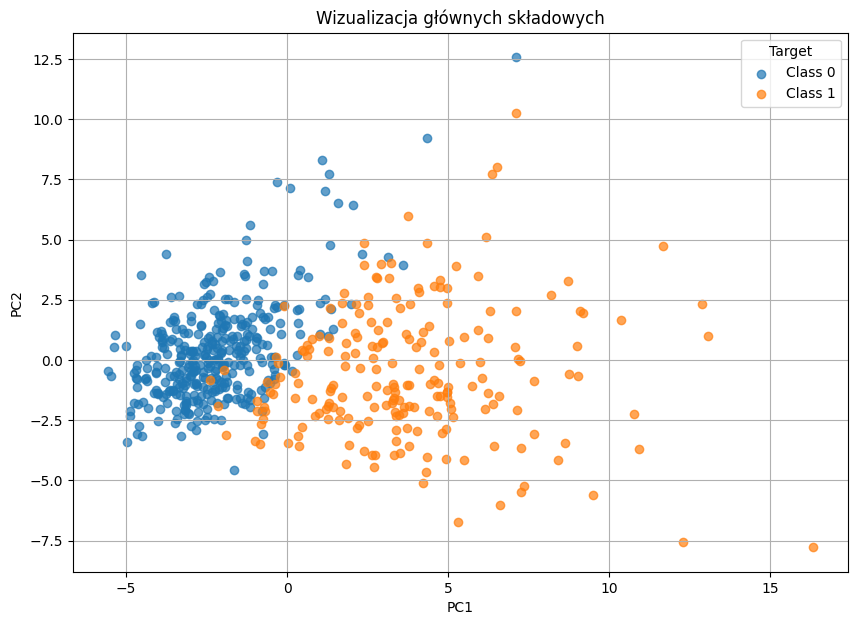

In [393]:
X_reduced['Target'] = y.values

plt.figure(figsize=(10, 7))
for target_value in [0, 1]:
    subset = X_reduced[X_reduced['Target'] == target_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=f"Class {target_value}", alpha=0.7)

plt.title('Wizualizacja głównych składowych')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Target')
plt.grid(True)
plt.show()

1.5. Wyświetlenie składowych i zależności:

1.5.1. Atrybut components_ – po dopasowaniu transformatora należy wyświetlić atrybut
components_, aby zobaczyć macierz składowych głównych. Składowe te
reprezentują wektory własne, które określają kierunki maksymalnej zmienności
danych.

In [394]:
components_matrix = pd.DataFrame(pca.components_, columns=X.columns, index=['PC1', 'PC2'])

components_matrix

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
PC1,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
PC2,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339


1.5.2. Mapa cieplna – należy wykorzystać mapę cieplną do przedstawienia relacji między
składowymi głównymi a oryginalnymi zmiennymi. Każda zmienna wejściowa (z
30-wymiarowego zbioru danych) jest reprezentowana w odniesieniu do głównych
składowych.

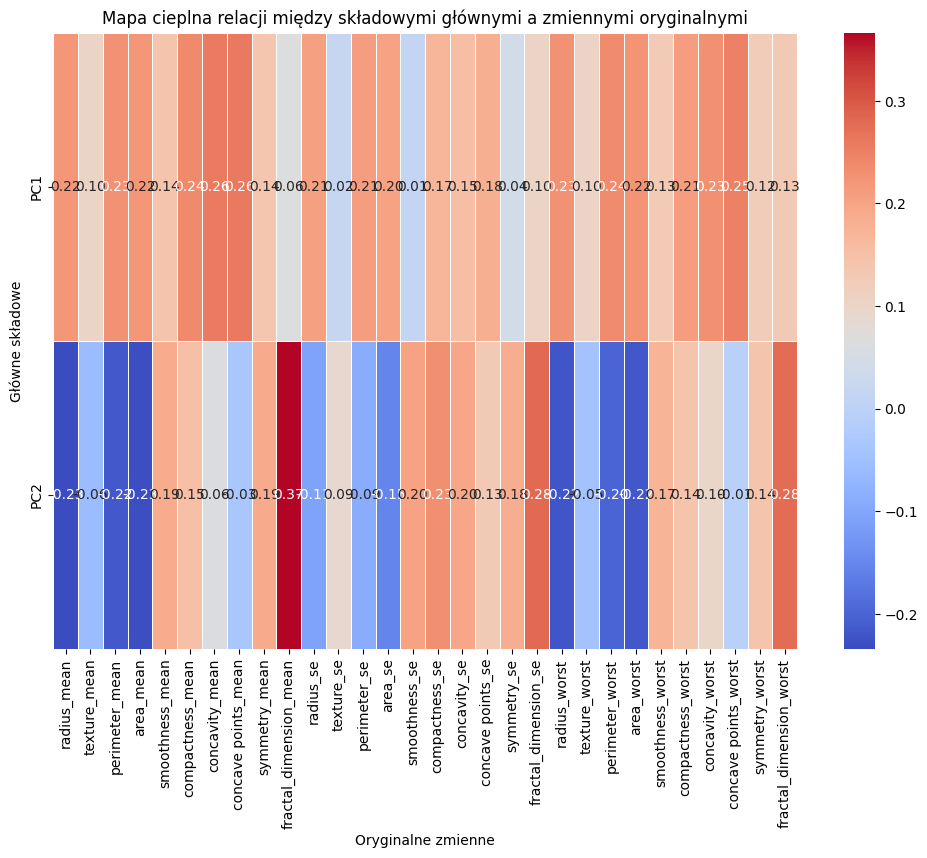

In [395]:
plt.figure(figsize=(12, 8))
sns.heatmap(components_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa cieplna relacji między składowymi głównymi a zmiennymi oryginalnymi')
plt.xlabel('Oryginalne zmienne')
plt.ylabel('Główne składowe')
plt.show()

1.6. Analiza wariancji:

1.6.1. Wariancja składowych - jaki procent wariancji wyjaśniają poszczególne składowe
(PC1 i PC2).

In [396]:
explained_variance_ratio = pca.explained_variance_ratio_

explained_variance_ratio_percentage = explained_variance_ratio * 100
explained_variance_ratio_percentage

array([44.27202561, 18.97118204])

1.6.2. Wariancja całkowita – jaki procent całkowitej wariancji danych jest wyjaśniany
przez dwie wybrane składowe.

In [397]:
total_explained_variance = explained_variance_ratio.sum() * 100

total_explained_variance

63.243207651559445

1.6.3. Liczba składowych dla 95% i 99% wariancji – obliczenie liczby składowych, które
pozwalają wyjaśnić ponad 905% i 99% całkowitej wariancji.

In [398]:
pca_full = PCA().fit(X_standardized)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

components_for_95 = (cumulative_variance >= 0.95).argmax() + 1
components_for_99 = (cumulative_variance >= 0.99).argmax() + 1

components_for_95, components_for_99

(10, 17)

1.6.4. Wykres wariancji od liczby składowych – zobrazowanie zależności między liczbą
składowych a wariancją, aby lepiej zrozumieć, jak szybko maleje wkład kolejnych
składowych w całkowitą wariancję danych.

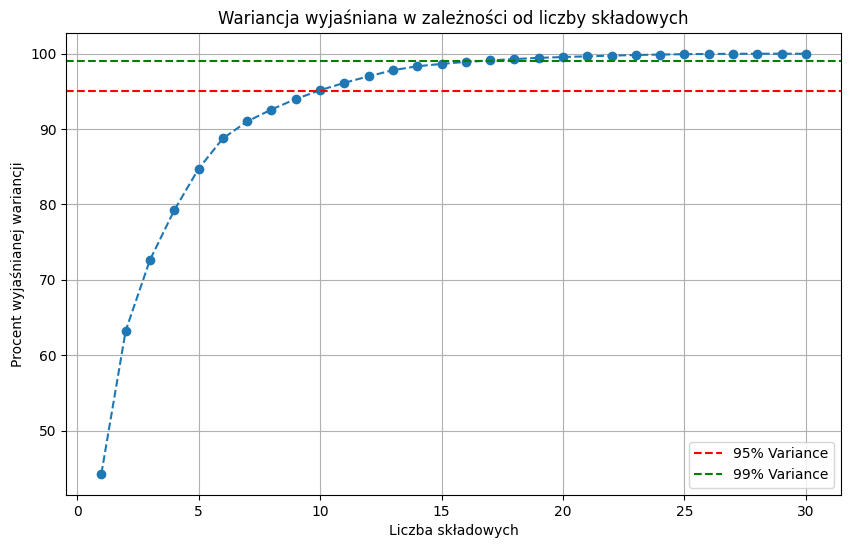

In [399]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--')
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=99, color='g', linestyle='--', label='99% Variance')
plt.title('Wariancja wyjaśniana w zależności od liczby składowych')
plt.xlabel('Liczba składowych')
plt.ylabel('Procent wyjaśnianej wariancji')
plt.legend()
plt.grid(True)
plt.show()

1.7. Przeprowadzenie PCA na danych oryginalnych (pomijając standaryzację w kroku 2.1)
i należy wykonać pozostałe kroki (od 2.2 do końca) na oryginalnych danych, aby
porównać wpływ standaryzacji na wyniki PCA.

In [ ]:
pca_raw = PCA()
pca_raw.fit(data)
explained_variance_ratio_raw = pca_raw.explained_variance_ratio_

In [401]:
first_two_variance_raw = explained_variance_ratio_raw[:2]
combined_variance_two_raw = np.sum(first_two_variance_raw)
components_95_raw = np.argmax(np.cumsum(explained_variance_ratio_raw) >= 0.95) + 1
components_99_raw = np.argmax(np.cumsum(explained_variance_ratio_raw) >= 0.99) + 1

In [402]:
first_two_variance_raw, combined_variance_two_raw

(array([0.98204444, 0.01617648]), 0.9982209233277914)

In [403]:
components_95_raw, components_99_raw

(1, 2)

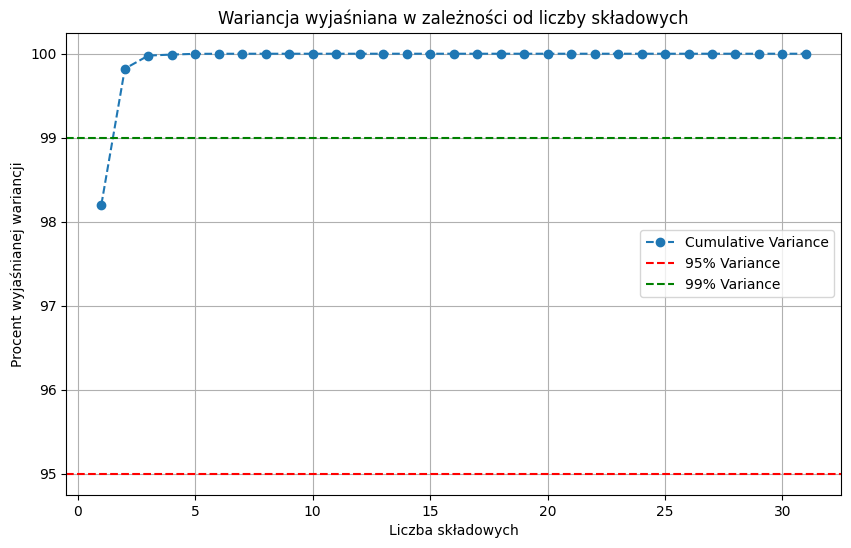

In [404]:
cumulative_variance = np.cumsum(explained_variance_ratio_raw)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--', label='Cumulative Variance')
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=99, color='g', linestyle='--', label='99% Variance')
plt.title('Wariancja wyjaśniana w zależności od liczby składowych')
plt.xlabel('Liczba składowych')
plt.ylabel('Procent wyjaśnianej wariancji')
plt.legend()
plt.grid(True)
plt.show()

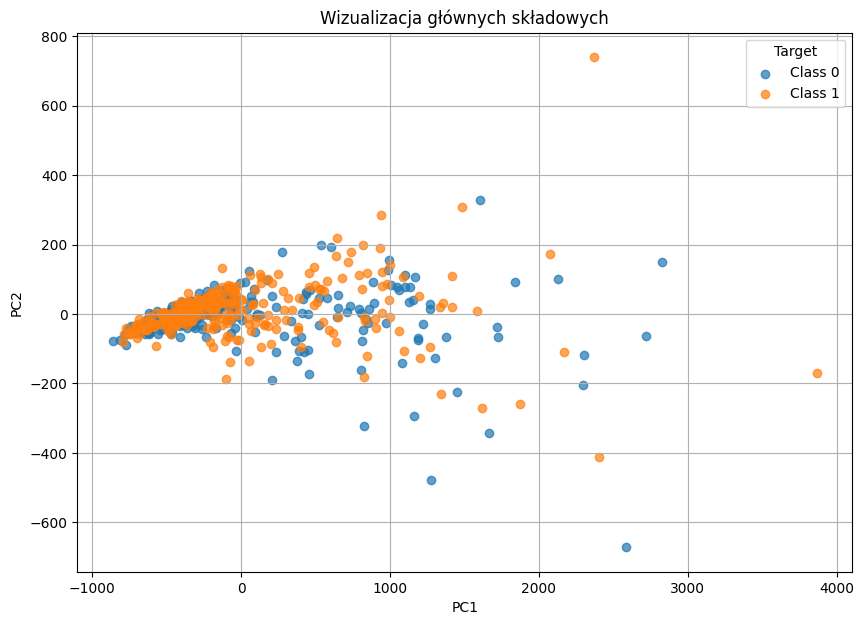

In [ ]:
pca_raw = PCA(n_components=2)
pca_transformed_raw = pca_raw.fit_transform(data)
target = np.random.randint(0, 2, size=data.shape[0])  

pc1_raw = pca_transformed_raw[:, 0]
pc2_raw = pca_transformed_raw[:, 1]

X_reduced = pd.DataFrame({
    'PC1': pc1_raw,
    'PC2': pc2_raw,
    'Target': target  
})

plt.figure(figsize=(10, 7))
for target_value in [0, 1]:
    subset = X_reduced[X_reduced['Target'] == target_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=f"Class {target_value}", alpha=0.7)

plt.title('Wizualizacja głównych składowych')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Target')
plt.grid(True)
plt.show()

Wyjaśniona wariancja dla PC1: 98.20%
Wyjaśniona wariancja dla PC2: 1.62%
Łączna wyjaśniona wariancja dla dwóch składowych: 99.82%

Zadanie 2. Implementacja analizy PCA dla danych obrazów cyfr.

2.1. Przygotowanie danych:

2.1.1. Sprawdzenie kompletności danych.

In [406]:
digits_data = pd.read_csv('digits.csv')

missing_data = digits_data.isnull().sum()

missing_data

pixel_0_0       0
pixel_0_1       0
pixel_0_2       0
pixel_0_3       0
pixel_0_4       0
               ..
pixel_7_4       0
pixel_7_5       0
pixel_7_6       0
pixel_7_7       0
number_label    0
Length: 65, dtype: int64

2.1.2. Przygotowanie ramki danych piksele – utworzenie df_pixels.

In [407]:
df_pixels = digits_data.drop(columns=['number_label']) 

df_pixels.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


2.1.3. Przykładowa reprezentacja obrazu – należy pobrać pierwszy wiersz danych z
obiektu df_pixels jako reprezentację jednego obrazu cyfry.

In [408]:
image_representation = df_pixels.iloc[0].values.reshape(8, 8)

image_representation

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

2.1.4. Wizualizacja obrazu – należy użyć Matplotlib lub Seaborn do wyświetlenia obrazu
cyfry z odpowiednią mapą kolorów, aby zobaczyć graficzną reprezentację wartości
pikseli.

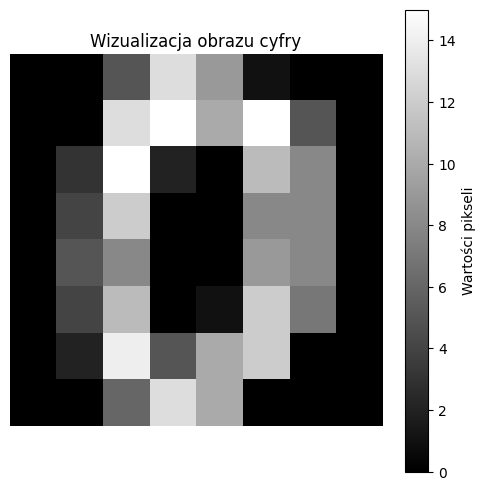

In [409]:
plt.figure(figsize=(6, 6))
plt.imshow(image_representation, cmap='gray', interpolation='nearest')
plt.title('Wizualizacja obrazu cyfry')
plt.colorbar(label='Wartości pikseli')
plt.axis('off')
plt.show()

2.2. Implementacja PCA:

2.2.1. Standaryzacja danych.

In [410]:
scaler = StandardScaler()
df_pixels_standardized = pd.DataFrame(scaler.fit_transform(df_pixels), columns=df_pixels.columns)

df_pixels_standardized.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,-0.335016,-0.043081,0.274072,-0.664478,-0.844129,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,0.086719,0.208293,-0.366771,-1.146647,-0.505670,-0.196008
1,0.0,-0.335016,-1.094937,0.038648,0.268751,-0.138020,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-0.249010,0.849632,0.548561,-0.505670,-0.196008
2,0.0,-0.335016,-1.094937,-1.844742,0.735366,1.097673,-0.409724,-0.125023,-0.059078,-0.624009,...,0.259230,-0.209785,-0.023596,-0.299081,-1.089383,-2.078218,-0.164037,1.565686,1.695137,-0.196008
3,0.0,-0.335016,0.377661,0.744919,0.268751,-0.844129,-0.409724,-0.125023,-0.059078,1.879691,...,1.072563,-0.209785,-0.023596,-0.299081,0.282736,0.208293,0.241430,0.379040,-0.505670,-0.196008
4,0.0,-0.335016,-1.094937,-2.551014,-0.197863,-1.020657,-0.409724,-0.125023,-0.059078,-0.624009,...,-0.757436,-0.209785,-0.023596,-0.299081,-1.089383,-2.306869,0.849632,-0.468564,-0.505670,-0.196008


2.2.2. Redukcja wymiarowości do 2 składowych głównych (rzutowanie przestrzeni 64-
wymiarowej na przestrzeń dwuwymiarową).

In [411]:
pca = PCA(n_components=2)
df_pixels_pca = pd.DataFrame(pca.fit_transform(df_pixels_standardized), columns=['PC1', 'PC2'])

df_pixels_pca.head()

,PC1,PC2
0,-1.914214,-0.954502
1,-0.588980,0.924636
2,-1.302039,-0.317189
3,3.020770,-0.868772
4,-4.528949,-1.093480


2.2.3. Dopasowanie PCA do danych – dopasowanie transformatora PCA do zestawu
danych, w celu uzyskania dwóch głównych składowych.

In [412]:
pca.fit(df_pixels_standardized)

principal_components = pca.components_

principal_components

array([[-0.        ,  0.18223392,  0.285868  ,  0.22036967, -0.02516956,
        -0.00949725, -0.0524765 , -0.06269499,  0.03470727,  0.24553368,
         0.22915174, -0.10794381,  0.03620209,  0.03871159, -0.08378077,
        -0.09277502,  0.01669934,  0.1367165 , -0.06305075, -0.12287927,
         0.14819348, -0.02348425, -0.1711997 , -0.10420837, -0.00394882,
        -0.1163897 , -0.18820473,  0.0658604 ,  0.14353257, -0.12820705,
        -0.18062075, -0.05270917, -0.        , -0.23890251, -0.23500613,
        -0.00509137, -0.01310881, -0.15911618, -0.12939416, -0.        ,
        -0.05559906, -0.18715707, -0.15353371, -0.04682572, -0.11089272,
        -0.10720947,  0.01792652, -0.00227271, -0.02881729,  0.040868  ,
         0.11027068,  0.0318244 , -0.07904945,  0.06832147,  0.12124707,
         0.04877119, -0.00183586,  0.16039569,  0.27985301,  0.19444929,
         0.01777381,  0.103198  ,  0.1198106 ,  0.07149362],
       [ 0.        ,  0.04702701,  0.0595648 , -0.02080385,  0.

2.2.4. Wyświetlenie atrybutu components_

In [413]:
components_matrix = pd.DataFrame(principal_components, columns=df_pixels.columns, index=['PC1', 'PC2'])

components_matrix

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
PC1,-0.0,0.182234,0.285868,0.220370,-0.025170,-0.009497,-0.052476,-0.062695,0.034707,0.245534,...,0.121247,0.048771,-0.001836,0.160396,0.279853,0.194449,0.017774,0.103198,0.119811,0.071494
PC2,0.0,0.047027,0.059565,-0.020804,0.155903,0.274133,0.249733,0.145832,-0.001027,0.027619,...,-0.257752,-0.115002,0.004883,0.044498,0.081400,-0.009905,-0.251934,-0.242618,-0.165089,-0.071329


2.2.5. Wariancja poszczególnych składowych – należy sprawdzić, ile wariancji wyjaśnia
każda z głównych składowych.

In [414]:
explained_variance_ratio = pca.explained_variance_ratio_

explained_variance_ratio_percentage = explained_variance_ratio * 100
explained_variance_ratio_percentage

array([12.0339161,  9.5610544])

2.2.6. Wariancja dwóch składowych – określenie, ile całkowitej wariancji wyjaśniają dwie
składowe.

In [415]:
total_explained_variance = explained_variance_ratio.sum() * 100

total_explained_variance

21.59497050083281

2.2.7. Liczba składowych dla 95% i 99% wariancji – wyznaczenie liczby składowych
potrzebnych do wyjaśnienia odpowiednio 95% i 99% wariancji.

In [416]:
pca_full = PCA().fit(df_pixels_standardized)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

components_for_95 = (cumulative_variance >= 0.95).argmax() + 1
components_for_99 = (cumulative_variance >= 0.99).argmax() + 1

components_for_95, components_for_99

(40, 54)

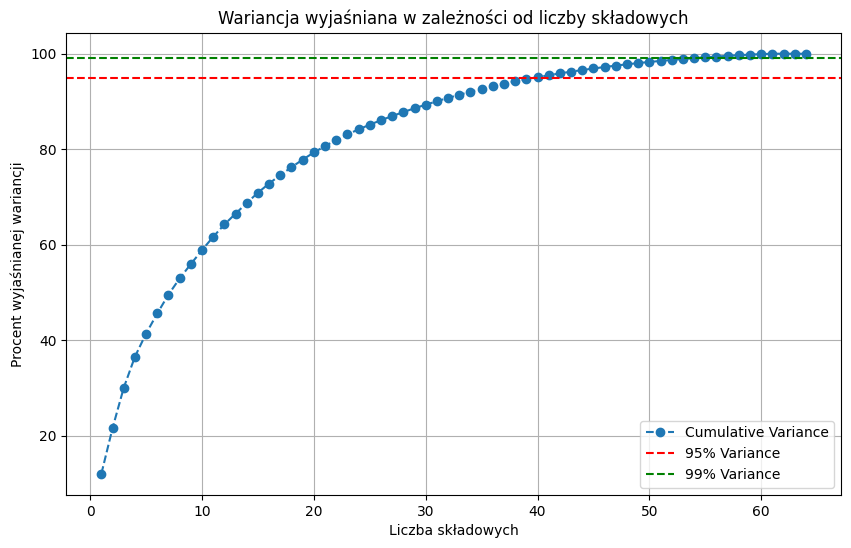

In [417]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--', label='Cumulative Variance')
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=99, color='g', linestyle='--', label='99% Variance')
plt.title('Wariancja wyjaśniana w zależności od liczby składowych')
plt.xlabel('Liczba składowych')
plt.ylabel('Procent wyjaśnianej wariancji')
plt.legend()
plt.grid(True)
plt.show()

2.2.8. Wizualizacja rozrzutu cyfr w dwuwymiarowej przestrzeni PCA – utwórz wykres
rozrzutu, na którym cyfry są oznaczone kolorami lub etykietami na podstawie
kolumny 'number_label'.

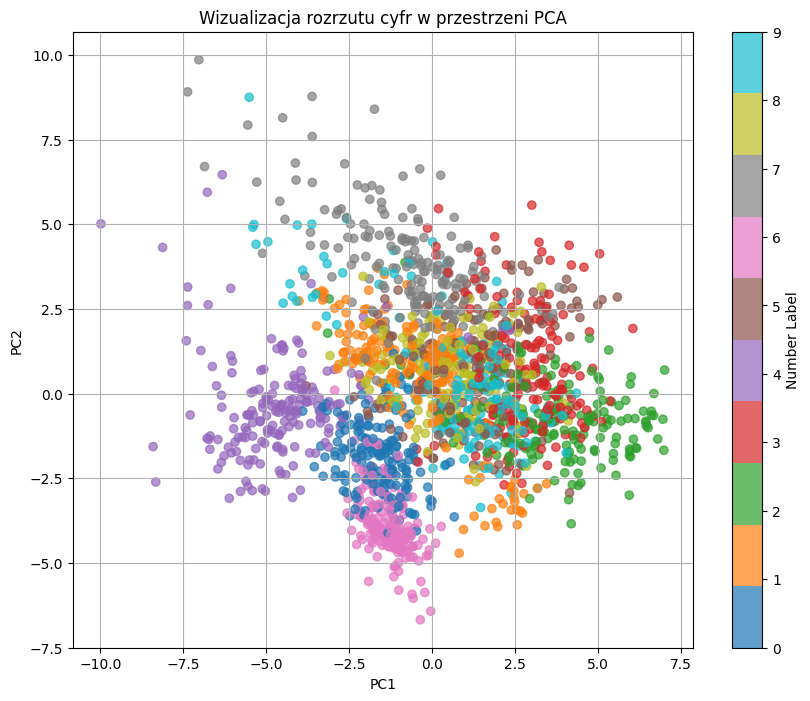

In [418]:
df_pixels_pca['number_label'] = digits_data['number_label']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pixels_pca['PC1'], df_pixels_pca['PC2'], 
                      c=df_pixels_pca['number_label'], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Number Label')
plt.title('Wizualizacja rozrzutu cyfr w przestrzeni PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

2.2.9. Analiza rozróżnialności cyfr – określenie, które cyfry są najlepiej rozróżnialne, a
które najsłabiej.

In [419]:
centroids = df_pixels_pca.groupby('number_label')[['PC1', 'PC2']].mean()

distances = pd.DataFrame(
    squareform(pdist(centroids, metric='euclidean')),
    index=centroids.index,
    columns=centroids.index
)

most_distinguishable = distances.stack().idxmax()
least_distinguishable = distances.stack().idxmin()

most_distinguishable, distances.loc[most_distinguishable], least_distinguishable, distances.loc[least_distinguishable]

((2, 4), 8.30273012642445, (0, 0), 0.0)

Najlepiej rozróżnialne cyfry: 2 i 4, z największą odległością między centroidami wynoszącą 8.30.
Najmniej rozróżnialne cyfry: 0 i 0, co wskazuje, że te same klasy mają zerową odległość (oczywiste, ponieważ są identyczne).

2.2.10. Możliwość klasyfikacji – ocena, czy dwie główne składowe mogą być
wystarczające do klasyfikacji cyfr.

In [420]:
X_pca = df_pixels_pca[['PC1', 'PC2']]
y_labels = df_pixels_pca['number_label']

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_labels, test_size=0.3, random_state=42)

classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

accuracy, classification_rep

(0.5351851851851852,
 '              precision    recall  f1-score   support\n\n           0       0.64      0.66      0.65        53\n           1       0.38      0.50      0.43        50\n           2       0.56      0.60      0.58        47\n           3       0.34      0.26      0.29        54\n           4       0.90      0.92      0.91        60\n           5       0.34      0.23      0.27        66\n           6       0.83      0.83      0.83        53\n           7       0.67      0.75      0.71        55\n           8       0.29      0.33      0.30        43\n           9       0.30      0.31      0.30        59\n\n    accuracy                           0.54       540\n   macro avg       0.52      0.54      0.53       540\nweighted avg       0.53      0.54      0.53       540\n')

Dokładność klasyfikacji wynosi 53.52%, co jest zgodne z wcześniejszą analizą, że dwie główne składowe nie są wystarczające do skutecznego rozróżniania wszystkich cyfr.

Cyfry 4 i 6 mają wysoką skuteczność klasyfikacji z wartością F1 bliską 0.90.
Cyfry 3, 5, 8 i 9 są klasyfikowane najsłabiej, z F1-score około 0.27–0.30.
Macro avg i weighted avg wskazują na ogólną skuteczność modelu, która jest niska.

2.3. Rozszerzenie PCA na trzy składowe główne:

2.3.1. PCA dla 3 składowych – wykonanie PCA na tym samym zbiorze danych, dla liczby
składowych ustawionych na 3.

In [421]:
pca_3 = PCA(n_components=3)
df_pixels_pca_3 = pd.DataFrame(pca_3.fit_transform(df_pixels_standardized), columns=['PC1', 'PC2', 'PC3'])

df_pixels_pca_3.head()

,PC1,PC2,PC3
0,-1.914214,-0.954502,-3.946035
1,-0.588980,0.924636,3.924755
2,-1.302039,-0.317189,3.023333
3,3.020770,-0.868772,-0.801744
4,-4.528949,-1.093480,0.973121


2.3.2. Wariancja poszczególnych składowych – sprawdzenie wariancji wyjaśnianej przez
każdą z trzech głównych składowych.

In [422]:
explained_variance_ratio_3 = pca_3.explained_variance_ratio_

explained_variance_ratio_3_percentage = explained_variance_ratio_3 * 100
explained_variance_ratio_3_percentage

array([12.0339161 ,  9.5610544 ,  8.44441489])

2.3.3. Wariancja dla trzech składowych – ile całkowitej wariancji wyjaśniają trzy główne
składowe?

In [423]:
total_explained_variance_3 = explained_variance_ratio_3.sum() * 100

total_explained_variance_3

30.039385393457362

2.3.4. Wizualizacja w 3D – utworzenie wykresu 3D dla zbioru danych w przestrzeni trzech
głównych składowych PCA, na którym cyfry są oznaczone kolorami lub etykietami
na podstawie kolumny 'number_label'.

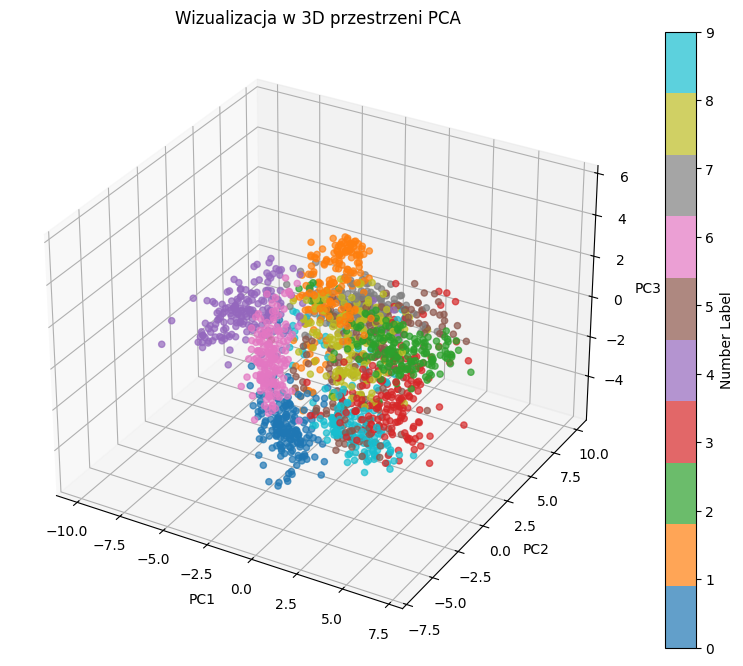

In [424]:
df_pixels_pca_3['number_label'] = digits_data['number_label']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pixels_pca_3['PC1'], 
    df_pixels_pca_3['PC2'], 
    df_pixels_pca_3['PC3'], 
    c=df_pixels_pca_3['number_label'], 
    cmap='tab10', 
    alpha=0.7
)

ax.set_title('Wizualizacja w 3D przestrzeni PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.colorbar(scatter, label='Number Label')
plt.show()

2.3.5. Analiza rozróżnialności cyfr – określenie, które cyfry są najlepiej rozróżnialne, a
które najsłabiej.

In [425]:
centroids_3d = df_pixels_pca_3.groupby('number_label')[['PC1', 'PC2', 'PC3']].mean()

distances_3d = pd.DataFrame(
    squareform(pdist(centroids_3d, metric='euclidean')),
    index=centroids_3d.index,
    columns=centroids_3d.index
)

most_distinguishable_3d = distances_3d.stack().idxmax()
least_distinguishable_3d = distances_3d.stack().idxmin()

most_distinguishable_3d, distances_3d.loc[most_distinguishable_3d], least_distinguishable_3d, distances_3d.loc[least_distinguishable_3d]


((2, 4), 8.317576993481765, (0, 0), 0.0)

2.4. Przeprowadzenie PCA na danych oryginalnych (od kroku punktu 2.2. kroku 2.2.2
pomijając standaryzację, do punktu 2.3. włącznie).

In [426]:
pca = PCA(n_components=2)
df_pixels_pca = pd.DataFrame(pca.fit_transform(df_pixels), columns=['PC1', 'PC2'])

df_pixels_pca.head()

,PC1,PC2
0,-1.259466,-21.274883
1,7.957611,20.768699
2,6.991923,9.955986
3,-15.906105,-3.332464
4,23.306867,-4.269061


In [427]:
pca.fit(df_pixels)

principal_components = pca.components_

principal_components

array([[ 0.00000000e+00, -1.73094651e-02, -2.23428835e-01,
        -1.35913304e-01, -3.30323092e-02, -9.66340844e-02,
        -8.32943805e-03,  2.26900082e-03, -3.20516495e-04,
        -1.19308905e-01, -2.44451676e-01,  1.48512745e-01,
        -4.67319410e-02, -2.17740744e-01, -1.48136776e-02,
         4.47779518e-03, -4.94136398e-05, -7.95419375e-02,
         8.33951454e-02,  2.15915342e-01, -1.72126801e-01,
        -1.63712098e-01,  2.86444452e-02,  4.23251803e-03,
         9.85488574e-05,  6.42319144e-02,  2.54093316e-01,
        -3.56771026e-02, -2.09462569e-01, -4.31311420e-02,
         5.13118688e-02,  2.13422732e-04,  0.00000000e+00,
         1.59950883e-01,  3.68690774e-01,  1.64406827e-01,
         8.52007908e-02,  3.72982855e-02,  2.15866980e-02,
         0.00000000e+00,  1.28865585e-03,  1.06945287e-01,
         3.03067457e-01,  2.47813041e-01,  2.09637296e-01,
         1.22325219e-02, -3.69458497e-02,  1.61485028e-03,
         6.93023548e-04, -8.35144239e-03, -5.58598986e-0

In [428]:
components_matrix = pd.DataFrame(principal_components, columns=df_pixels.columns, index=['PC1', 'PC2'])

components_matrix

explained_variance_ratio = pca.explained_variance_ratio_

explained_variance_ratio_percentage = explained_variance_ratio * 100
explained_variance_ratio_percentage

array([14.89059358, 13.61877124])

In [429]:
total_explained_variance = explained_variance_ratio.sum() * 100

total_explained_variance

28.50936482369929

In [430]:
pca_full = PCA().fit(df_pixels_standardized)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

components_for_95 = (cumulative_variance >= 0.95).argmax() + 1
components_for_99 = (cumulative_variance >= 0.99).argmax() + 1

components_for_95, components_for_99

(40, 54)

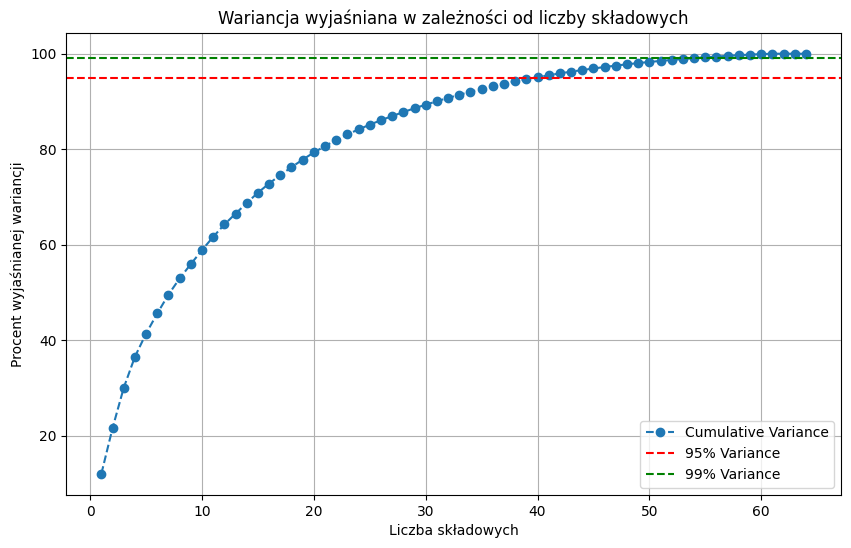

In [431]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='--', label='Cumulative Variance')
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=99, color='g', linestyle='--', label='99% Variance')
plt.title('Wariancja wyjaśniana w zależności od liczby składowych')
plt.xlabel('Liczba składowych')
plt.ylabel('Procent wyjaśnianej wariancji')
plt.legend()
plt.grid(True)
plt.show()

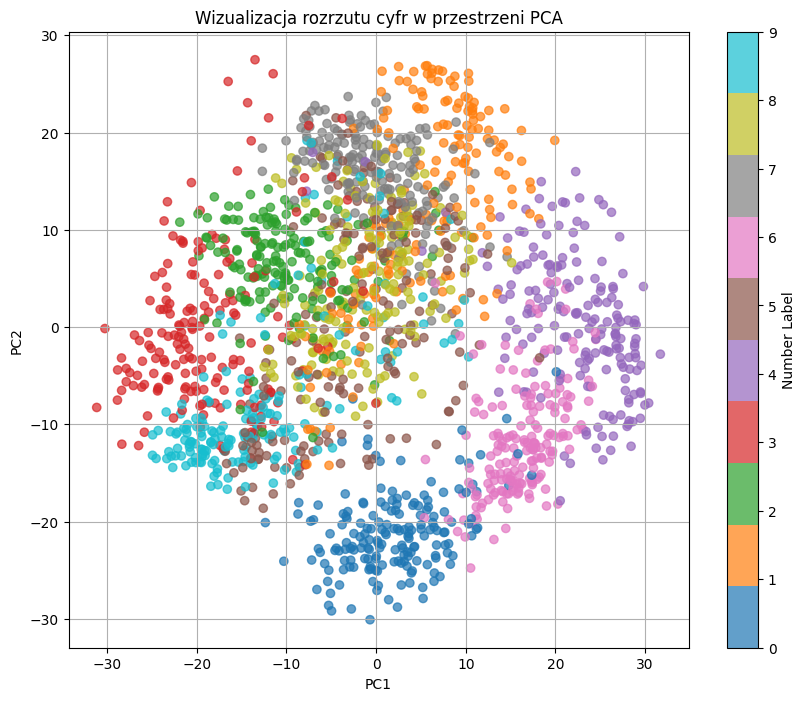

In [432]:
df_pixels_pca['number_label'] = digits_data['number_label']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pixels_pca['PC1'], df_pixels_pca['PC2'], 
                      c=df_pixels_pca['number_label'], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Number Label')
plt.title('Wizualizacja rozrzutu cyfr w przestrzeni PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

In [433]:
centroids = df_pixels_pca.groupby('number_label')[['PC1', 'PC2']].mean()

distances = pd.DataFrame(
    squareform(pdist(centroids, metric='euclidean')),
    index=centroids.index,
    columns=centroids.index
)

most_distinguishable = distances.stack().idxmax()
least_distinguishable = distances.stack().idxmin()

most_distinguishable, distances.loc[most_distinguishable], least_distinguishable, distances.loc[least_distinguishable] 

((3, 4), 40.92352363360996, (0, 0), 0.0)

In [434]:
X_pca = df_pixels_pca[['PC1', 'PC2']]
y_labels = df_pixels_pca['number_label']

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_labels, test_size=0.3, random_state=42)

classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

accuracy, classification_rep

(0.6203703703703703,
 '              precision    recall  f1-score   support\n\n           0       0.81      0.87      0.84        53\n           1       0.59      0.52      0.55        50\n           2       0.59      0.70      0.64        47\n           3       0.67      0.65      0.66        54\n           4       0.92      0.75      0.83        60\n           5       0.24      0.12      0.16        66\n           6       0.69      0.83      0.75        53\n           7       0.61      0.76      0.68        55\n           8       0.34      0.44      0.38        43\n           9       0.63      0.63      0.63        59\n\n    accuracy                           0.62       540\n   macro avg       0.61      0.63      0.61       540\nweighted avg       0.61      0.62      0.61       540\n')

In [435]:
pca_3 = PCA(n_components=3)
df_pixels_pca_3 = pd.DataFrame(pca_3.fit_transform(df_pixels), columns=['PC1', 'PC2', 'PC3'])

df_pixels_pca_3.head()

,PC1,PC2,PC3
0,-1.259466,-21.274883,9.463055
1,7.957611,20.768699,-4.439506
2,6.991923,9.955986,-2.958558
3,-15.906105,-3.332464,-9.824372
4,23.306867,-4.269061,5.675129


In [436]:
explained_variance_ratio_3 = pca_3.explained_variance_ratio_

explained_variance_ratio_3_percentage = explained_variance_ratio_3 * 100
explained_variance_ratio_3_percentage

array([14.89059358, 13.61877124, 11.79459376])

In [437]:
total_explained_variance_3 = explained_variance_ratio_3.sum() * 100

total_explained_variance_3

40.30395858767508

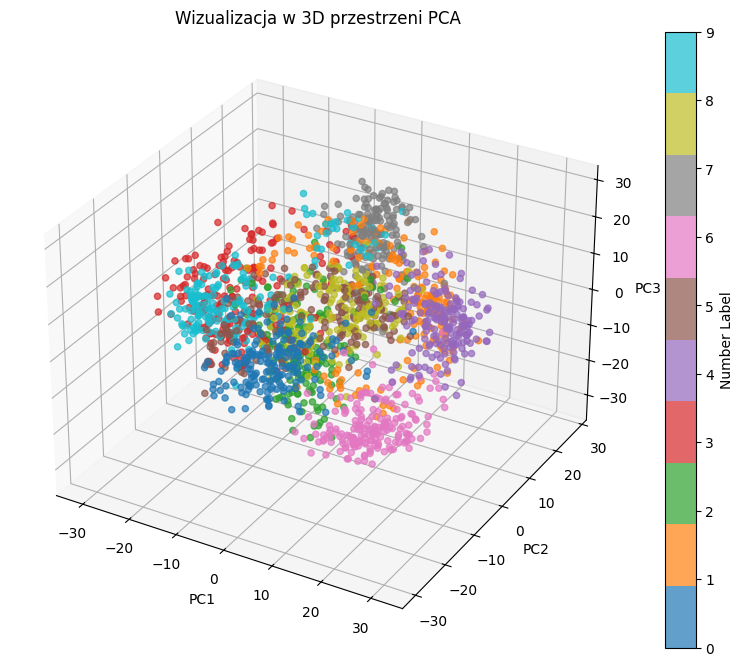

In [438]:
df_pixels_pca_3['number_label'] = digits_data['number_label']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pixels_pca_3['PC1'], 
    df_pixels_pca_3['PC2'], 
    df_pixels_pca_3['PC3'], 
    c=df_pixels_pca_3['number_label'], 
    cmap='tab10', 
    alpha=0.7
)

ax.set_title('Wizualizacja w 3D przestrzeni PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.colorbar(scatter, label='Number Label')
plt.show()

In [ ]:
centroids_3d = df_pixels_pca_3.groupby('number_label')[['PC1', 'PC2', 'PC3']].mean()

distances_3d = pd.DataFrame(
    squareform(pdist(centroids_3d, metric='euclidean')),
    index=centroids_3d.index,
    columns=centroids_3d.index
)

most_distinguishable_3d = distances_3d.stack().idxmax()
least_distinguishable_3d = distances_3d.stack().idxmin()

most_distinguishable_3d, distances_3d.loc[most_distinguishable_3d], least_distinguishable_3d, distances_3d.loc[least_distinguishable_3d] 


((3, 4), 41.61783496619957, (0, 0), 0.0)